# Comparação do Uniceub-BRB-Brasília nas temporadas 2024/2025 e 2025/2026

* PPG
* Ast/TO
* ORtg
* DRtg
* eDiff
* TS%

In [1]:
# Biblioteca de processamento de dataframes
import pandas as pd
import numpy as np
# Bibliotecas de visualização de dados
import seaborn as sns
import matplotlib  as plt
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Biblioteca de criação do shot chart
from mplbasketball import Court
from mplbasketball.utils import transform


In [2]:
# Trazendo os dataframes
df_24 = pd.read_csv(r'Classificacao_NBB\NBB_24_teams.csv')
df_25 = pd.read_csv(r'Classificacao_NBB\NBB_25_teams.csv')

In [3]:
# Verificar se o dataframe foi importado corretamente
df_24.head()

,Team,PPG,FGM,FGA,FG%,3PM,3PA,3P%,FTM,FTA,...,TOV%,STL%,BLK%,ORtg,DRtg,eDiff,Pace,Ast/TO,W's,Win %
0,Flamengo,85.2,30.3,65.1,0.466,10.4,29.7,0.351,14.1,18.6,...,14.3,10.7,5.4,117.5,107.1,10.4,72.2,1.6,34,0.723
1,Franca,85.1,29.9,61.7,0.485,9.9,27.0,0.368,15.3,19.1,...,14.3,10.1,7.0,118.0,106.1,11.9,71.9,1.5,37,0.725
2,Corinthians,82.3,29.4,65.8,0.447,10.5,30.5,0.343,13.0,17.4,...,14.6,7.7,4.6,112.0,109.5,2.5,73.1,1.5,21,0.512
3,Pato Basquete,81.3,29.3,65.1,0.450,11.3,30.7,0.367,11.5,15.4,...,15.2,8.4,4.3,111.4,115.4,-3.9,72.9,1.3,13,0.351
4,Minas,81.1,29.7,65.4,0.453,9.1,26.6,0.341,12.8,18.4,...,14.9,9.8,8.5,111.6,98.0,13.5,72.8,1.3,39,0.830


In [4]:
# Listar as colunas do dataframe para ajudar na hora de criar o gráfico
df_24.columns

Index(['Team', 'PPG', 'FGM', 'FGA', 'FG%', '3PM', '3PA', '3P%', 'FTM', 'FTA',
       'FT%', 'ORB', 'DRB', 'RPG', 'APG', 'SPG', 'BPG', 'TOV', 'TS%', 'eFG%',
       'ORB%', 'DRB%', 'TRB%', 'AST%', 'TOV%', 'STL%', 'BLK%', 'ORtg', 'DRtg',
       'eDiff', 'Pace', 'Ast/TO', 'W's', 'Win %'],
      dtype='object')

In [5]:
# Gerar grafico de barras para comparar cada estatística do time do Brasília
team = "Uniceub-BRB-Brasilia"
stats = ["PPG", "Ast/TO", "ORtg", "DRtg", "eDiff", "TS%"]

# Filtrar linha do time
row_24 = df_24.loc[df_24["Team"] == team]
row_25 = df_25.loc[df_25["Team"] == team]

# Extrair valores na mesma ordem das estatísticas
def get_values(row, stats):
    if row.empty:
        return [None] * len(stats)
    return [row[s].values[0] if s in row.columns else None for s in stats]

y24 = get_values(row_24, stats)
y25 = get_values(row_25, stats)

# Converter TS% para percentual se estiver em proporção
if "TS%" in stats:
    idx = stats.index("TS%")
    if y24[idx] is not None:
        y24[idx] = y24[idx] * 100
    if y25[idx] is not None:
        y25[idx] = y25[idx] * 100

fig = go.Figure(
    data=[
        go.Bar(
            name="24/25",
            x=stats,
            y=y24,
            marker=dict(color="#1C2846"),
            legendgroup="24/25",
            hovertemplate="%{x}<br>24/25: %{y:.2f}<extra></extra>"
        ),
        go.Bar(
            name="25/26",
            x=stats,
            y=y25,
            marker=dict(color="#AB9034"),
            legendgroup="25/26",
            hovertemplate="%{x}<br>25/26: %{y:.2f}<extra></extra>"
        )
    ]
)

# Mostrar valores nas barras e agrupar lado a lado
fig.update_traces(texttemplate="%{y:.1f}", textposition="outside")
fig.update_layout(
    barmode="group",
    template="simple_white",
    title=dict(text="<b>Comparação Uniceub-BRB-Brasília</b>", font=dict(family="Segoe UI", size=20)),
    xaxis=dict(title="Estatística", tickfont=dict(family="Segoe UI"), tickangle=0),
    yaxis=dict(title="Valor", tickfont=dict(family="Segoe UI")),
    legend=dict(title="Temporada")
)

fig.show()

#fig.write_image("Analise_Bsb.png")

Baseado nos fatores que mais impactam as vitórias das equipes, segundo o gráfico de correlação de variáveis, podemos perceber que as maiores mudanças entre a temporada passada e a atual foram o aumento de pontos por partida e a melhora na eficiência defensiva (DRtg).

Como a equipe do Brasília ocupou a mesma posição na tabela da temporada regular nas duas edições, é necessário fazer mais uma análise comparativa baseada nos achados.

In [6]:
# Gerar grafico de barras para comparar cada estatística do time do Brasília
team = "Uniceub-BRB-Brasilia"
stats = ["FG%", "3P%", "FT%", "TRB%", "DRB"]

# Filtrar linha do time
row_24 = df_24.loc[df_24["Team"] == team]
row_25 = df_25.loc[df_25["Team"] == team]

# Extrair valores na mesma ordem das estatísticas
def get_values(row, stats):
    if row.empty:
        return [None] * len(stats)
    return [row[s].values[0] if s in row.columns else None for s in stats]

y24 = get_values(row_24, stats)
y25 = get_values(row_25, stats)

# Converter % para percentual se estiver em proporção
for idx, stat in enumerate(stats):
    if stat not in {"TRB%", "DRB"}:
        idx = stats.index(stat)
        if y24[idx] is not None:
            y24[idx] = y24[idx] * 100
        if y25[idx] is not None:
            y25[idx] = y25[idx] * 100

fig = go.Figure(
    data=[
        go.Bar(
            name="24/25",
            x=stats,
            y=y24,
            marker=dict(color="#1C2846"),
            legendgroup="24/25",
            hovertemplate="%{x}<br>24/25: %{y:.2f}<extra></extra>"
        ),
        go.Bar(
            name="25/26",
            x=stats,
            y=y25,
            marker=dict(color="#AB9034"),
            legendgroup="25/26",
            hovertemplate="%{x}<br>25/26: %{y:.2f}<extra></extra>"
        )
    ]
)

# Mostrar valores nas barras e agrupar lado a lado
fig.update_traces(texttemplate="%{y:.1f}", textposition="outside")
fig.update_layout(
    barmode="group",
    template="simple_white",
    title=dict(text="<b>Comparação Uniceub-BRB-Brasília</b>", font=dict(family="Segoe UI", size=20)),
    xaxis=dict(title="Estatística", tickfont=dict(family="Segoe UI"), tickangle=0),
    yaxis=dict(title="Valor", tickfont=dict(family="Segoe UI")),
    legend=dict(title="Temporada")
)

fig.show()

#fig.write_image("Analise_Bsb.png")

Pode-se inferir que as maiores diferenças estatísticas positivas entre as temporadas são o aumento percentual dos acertos de quadra (FG%), o percentual total de rebotes (TRB%) e a quantidade média de rebotes defensivos por jogo (DRB).

Com relação aos acertos de quadra, veremos mais adiante se é reflexo de uma concentração maior em tentativas de meia distância ou finalizações perto da cesta.

# Comparação estatística nos confrontos diretos com os 5 melhores times da liga

* PPG
* Ast/TO
* ORtg
* DRtg
* eDiff
* TS%

In [7]:
# Trazendo os data frames
df_Wadv = pd.read_csv(r'Df_Partidas\df_Wadv.csv')
df_Ladv = pd.read_csv(r'Df_Partidas\df_Ladv.csv')
df_Wbsb = pd.read_csv(r'Df_Partidas\df_Wbsb.csv')
df_Lbsb = pd.read_csv(r'Df_Partidas\df_Lbsb.csv')

In [8]:
df_Wbsb

,Player,Off,Def,Reb,Ast,PF,STL,TO,BLK,PTS,...,FGA,3PM,3PA,FTM,FTA,AST/TO,TS%,ORtg,DRtg,eDiff
0,Brasília,17.0,24.0,41.0,23.0,20.0,9.0,10.0,0.0,89.0,...,78.0,10.0,33.0,15.0,19.0,2.30,51.53,112.15,96.91,15.24
1,Brasília,9.0,24.0,33.0,21.0,15.0,5.0,10.0,4.0,85.0,...,63.0,10.0,28.0,11.0,13.0,2.10,61.85,121.92,114.70,7.22
2,Brasília,13.0,27.0,40.0,18.0,21.0,7.0,16.0,4.0,89.0,...,64.0,13.0,25.0,14.0,18.0,1.12,61.87,118.79,114.41,4.38
3,Brasília,10.0,30.0,40.0,21.0,15.0,9.0,12.0,5.0,80.0,...,69.0,9.0,35.0,19.0,24.0,1.75,50.28,98.09,95.17,2.92


In [9]:
# Gráfico de barras comparando desempenhos contra os adversários

# nomes das estatísticas e dos dataframes
stats = ["PTS", "AST/TO", "ORtg", "DRtg", "TS%"]
dfs = {
    "Adversários Vencem": df_Wadv,
    "Adversários Perdem": df_Ladv,
    "Brasília Vence": df_Wbsb,
    "Brasília Perde": df_Lbsb
}
colors = ["#1C2846", "#2E5A88", "#AB9034", "#D4B24A"]  # cores para as 4 barras

def safe_mean(df, col):
    """Retorna a média da coluna se existir e não estiver vazia; caso contrário np.nan."""
    if col not in df.columns:
        return np.nan
    # tenta converter para numérico (remove strings/valores inválidos)
    vals = pd.to_numeric(df[col], errors="coerce")
    return vals.mean()

for stat in stats:
    # calcular médias para cada dataframe
    means = []
    for label, df in dfs.items():
        m = safe_mean(df, stat)
        means.append(m)

    # se for TS% e estiver em proporção (0..1), converte para percentual
    # aqui assumimos que se média <= 1 então está em proporção
    if stat == "TS%":
        means = [m * 100 if (not np.isnan(m) and abs(m) <= 1) else m for m in means]

    # criar figura com 4 barras (uma por dataframe)
    fig = go.Figure(
        data=[
            go.Bar(
                x=list(dfs.keys()),
                y=means,
                marker=dict(color=colors),
                text=[f"{v:.2f}" if not np.isnan(v) else "" for v in means],
                textposition="outside",
                hovertemplate="%{x}<br>" + stat + ": %{y:.2f}<extra></extra>"
            )
        ]
    )

    fig.update_layout(
        title=dict(text=f"<b>{stat} — médias por grupo</b>", font=dict(family="Segoe UI", size=18)),
        xaxis=dict(title="Grupo", tickfont=dict(family="Segoe UI")),
        yaxis=dict(title=stat, tickfont=dict(family="Segoe UI")),
        template="simple_white"
    )

    fig.show()


#fig.write_image("Partidas_Bsb.png")

Quando comparamos as performances do Brasília contra os principais adversários na temporada atual podemos inferir que:

* Em termos de pontos por jogo, o Brasília ganha jogos quando marca mais pontos (+10.75), mas não limitando necessariamente os pontos do adversário. O que mostra uma predominancia ofensiva na equipe;
* Em termos de assistências e turnovers, a figura se repete e permite inferir que um ataque que comete menos turnovers por jogo auxilia nas vitórias da equipe (+ 0.43);
* Quando comparamos eficiências ofensivas, defensivas e líquidas, é possível confirmar os pontos anteriores porque a maior diferença, em termos de vitória e derrota, ocorre na diferença na eficiência ofensiva (+ 13.69);
* Em termos de aproveitamento de quadra corrigido (TS%), podemos inferir que existe uma diferença positiva percentual significativa quando o Brasília vence (+ 4.72%). Porém, para os adversários essa diferença se mostrou negativa, ou seja, quando vencem, têm um aproveitamento corrigido menor (- 4.38%).

Vamos comparar mais alguns fatores para tentar encontrar mais variáveis que podem impactar nas vitórias do Brasília.

In [10]:
# Listando as colunas para poder trabalha-las nos gráficos
df_Wbsb.columns

Index(['Player', 'Off', 'Def', 'Reb', 'Ast', 'PF', 'STL', 'TO', 'BLK', 'PTS',
       'FGM', 'FGA', '3PM', '3PA', 'FTM', 'FTA', 'AST/TO', 'TS%', 'ORtg',
       'DRtg', 'eDiff'],
      dtype='object')

In [11]:
# Segundo gráfico de comparação
stats = ["Def", "Reb", "FTM", "3PM"]
dfs = {
    "Adversários Vencem": df_Wadv,
    "Adversários Perdem": df_Ladv,
    "Brasília Vence": df_Wbsb,
    "Brasília Perde": df_Lbsb
}
colors = ["#1C2846", "#2E5A88", "#AB9034", "#D4B24A"]  # cores para as 4 barras

def safe_mean(df, col):
    if col not in df.columns:
        return np.nan
    vals = pd.to_numeric(df[col], errors="coerce")
    return vals.mean()

for stat in stats:
    means = []
    for label, df in dfs.items():
        m = safe_mean(df, stat)
        means.append(m)

    fig = go.Figure(
    data=[
        go.Bar(
            x=list(dfs.keys()),
            y=means,
            marker=dict(color=colors),
            text=[f"{v:.2f}" if not np.isnan(v) else "" for v in means],
            textposition="outside",
            hovertemplate="%{x}<br>" + stat + ": %{y:.2f}<extra></extra>"
        )
    ]
)

    fig.update_layout(
        title=dict(text=f"<b>{stat} — médias por grupo</b>", font=dict(family="Segoe UI", size=18)),
        xaxis=dict(title="Grupo", tickfont=dict(family="Segoe UI")),
        yaxis=dict(title=stat, tickfont=dict(family="Segoe UI")),
        template="simple_white"
    )

    fig.show()

Pode-se observar alguns pontos interessantes a partir dos gráficos:
* Os adversários registram, em média, 4.42 rebotes defensivos a mais quando vencem contra do time do Brasília. Isso pode ocorrer pelo fato do time do Brasília pegar menos rebotes ofensivos quando perdem e/ou errarem mais arremessos quando perdem;
* O time do Brasília não registrou diferença significativa nas estatísticas de rebotes (defensivos ou totais) nem de cestas de 3 pontos convertidas quando venceram ou perderam as partidas;
* O Brasília registrou uma diferença de 4.58 lances-livres convertidos quando vencem as partidas;
* Quando os adversários venceram as partidas registraram mais rebotes totais, porém registraram menos lances-livres convertidos e menos arremessos de 3 pontos convertidos (-2.83) também.

# Gráfico de arremessos dos adversários
## Arremessos errados

In [12]:
adv_e = pd.read_csv(r"D:\PyCharm 2025.3\Projeto_final_EBAC\Shot_Charts\ADV_Errados.csv")

In [13]:
# checagem do dataframe de coordenadas
adv_e.head()

,X,Y
0,-23.243689,48.534690
1,0.192097,48.342857
2,-23.243689,47.575510
3,23.408344,47.575510
4,-10.455543,27.624489


In [14]:
adv_e.describe()

,X,Y
count,521.000000,521.000000
mean,-2.162118,1.771873
std,17.318103,27.258289
min,-24.947306,-46.445060
25%,-18.549885,-15.587936
50%,-8.885019,1.534695
75%,14.380913,21.314308
max,24.469265,49.160988


In [15]:
'''
Como a importação de imagem em dataframe dos gráficos de arremesso vieram com as coordenadas em uma escala trocada, temos que renomear as colunas.
'''
def ajust_data(df, col_1, col_2):
     df_ajust = pd.DataFrame({col_1: df[col_1] * 1.88, col_2: df[col_2] * 0.53})
     return df_ajust

In [32]:
# Origem do gráfico e tipo de quadra
origin = "center"
court_type = "nba"
court = Court(origin=origin)
cmap_e = mcolors.LinearSegmentedColormap.from_list(
    "custom_cmap", ["#FFFFFF", "#5B6070"]
)
cmap_c = mcolors.LinearSegmentedColormap.from_list(
    "custom_cmap", ["#FFFFFF", "#AB9034"]
)
'''
Transformando coordenadas de quadra inteira horizontal, para meia quadra vertical
'''
def court_transform(df, col_1, col_2):
    x_v, y_v = transform(df[col_1],
                     df[col_2],
                     fr='h',
                     to='vd',
                     origin=origin,
                     court_type=court_type)
    return x_v, y_v

# Gerando os gráficos

def shot_cart(x, y, c_map, cor, cxe, eqi):
    fig, ax = plt.subplots(1,2, figsize=(16,8))

    # Gráfico 1: heatmap
    court.draw(ax[0], orientation = 'vd')
    ax[0].hexbin(
        x,
        y,
        gridsize=30,
        cmap=c_map,
        zorder=0
    )
    ax[0].set_title(f"Heatmap de {cxe} {eqi}", fontsize=16)

    # Gráfico 2: Concentração
    court.draw(ax[1], orientation = 'vd')
    ax[1].scatter(
        x,
        y,
        s=50,
        c= cor
    )

    ax[1].set_title(f"Concentração de {cxe} {eqi}", fontsize=16)

    plt.tight_layout()
    return fig,ax

In [17]:
adv_e = ajust_data(adv_e, 'X', 'Y')

In [18]:
adv_e.describe()

,X,Y
count,521.000000,521.000000
mean,-4.064781,0.939093
std,32.558034,14.446893
min,-46.900935,-24.615882
25%,-34.873784,-8.261606
50%,-16.703836,0.813388
75%,27.036116,11.296583
max,46.002218,26.055324


In [19]:
x_adv_e, y_adv_e = court_transform(adv_e, 'X', 'Y')

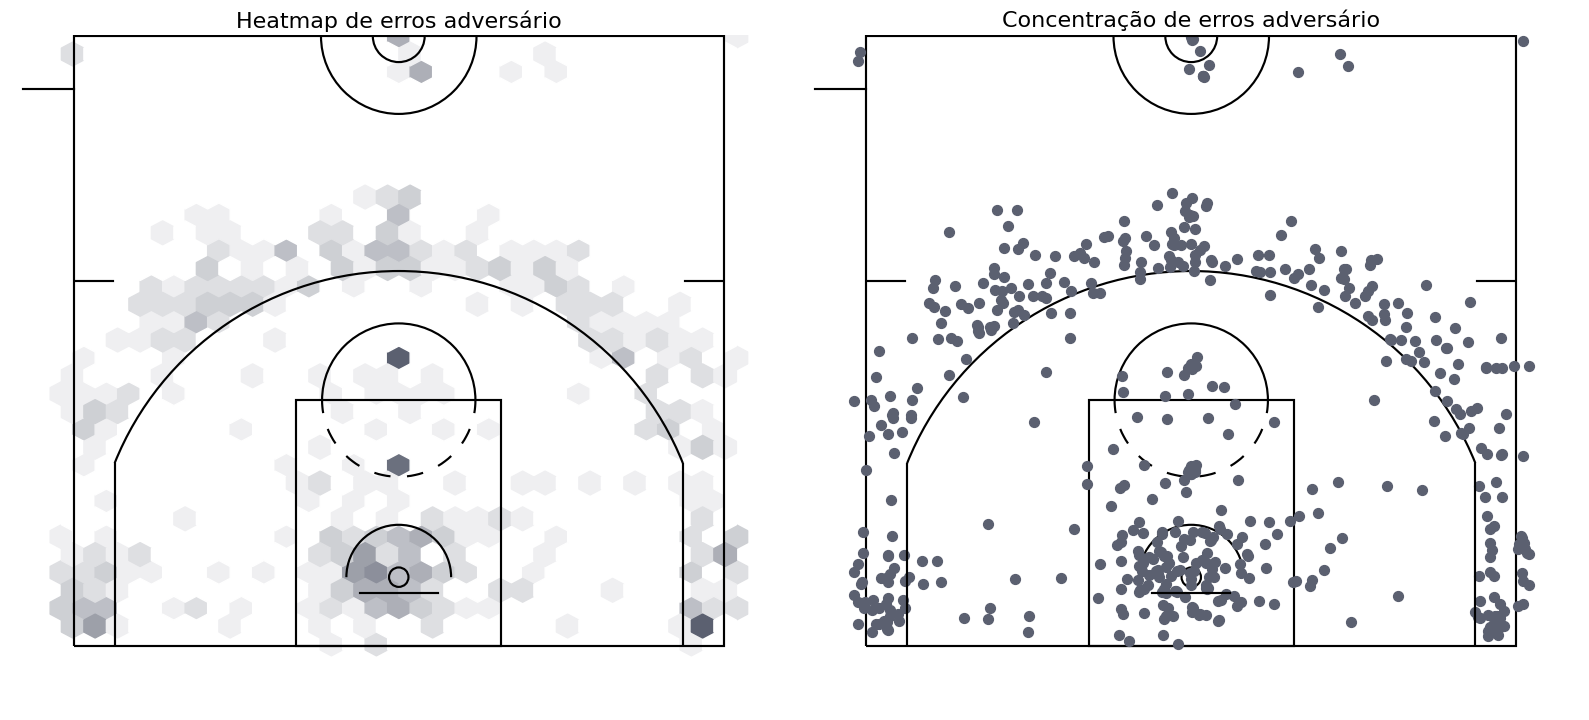

In [21]:
fig = shot_cart(x_adv_e, y_adv_e, cmap_e, "#5B6070", 'erros', 'adversário')

Observa-se que há uma concentração de erros no topo da linha de 3 pontos, na cabeça do garrafão, nas zonas mortas de 3 pontos e perto da cesta.

Os erros perto da cesta causam estranheza em um primeiro momento por ser, teoricamente, o local com maior chance de acertos. Logo, esses erros podem ser consequência de segundas chances criadas, rebotes ofensivos, ou algum trabalho de dobra defensiva.

## Arremessos convertidos

In [22]:
adv_c = pd.read_csv(r"D:\PyCharm 2025.3\Projeto_final_EBAC\Shot_Charts\ADV_Certos.csv")
adv_c.describe()

,X,Y
count,272.000000,272.000000
mean,0.005990,1.317709
std,19.067266,24.000095
min,-25.054773,-47.202766
25%,-20.993415,-3.937142
50%,-1.645923,0.226120
75%,21.435664,8.239239
max,24.338417,49.127556


In [23]:
adv_c = ajust_data(adv_c, 'X', 'Y')

adv_c.describe()

,X,Y
count,272.000000,272.000000
mean,0.011262,0.698386
std,35.846461,12.720050
min,-47.102973,-25.017466
25%,-39.467619,-2.086685
50%,-3.094335,0.119844
75%,40.299048,4.366797
max,45.756224,26.037605


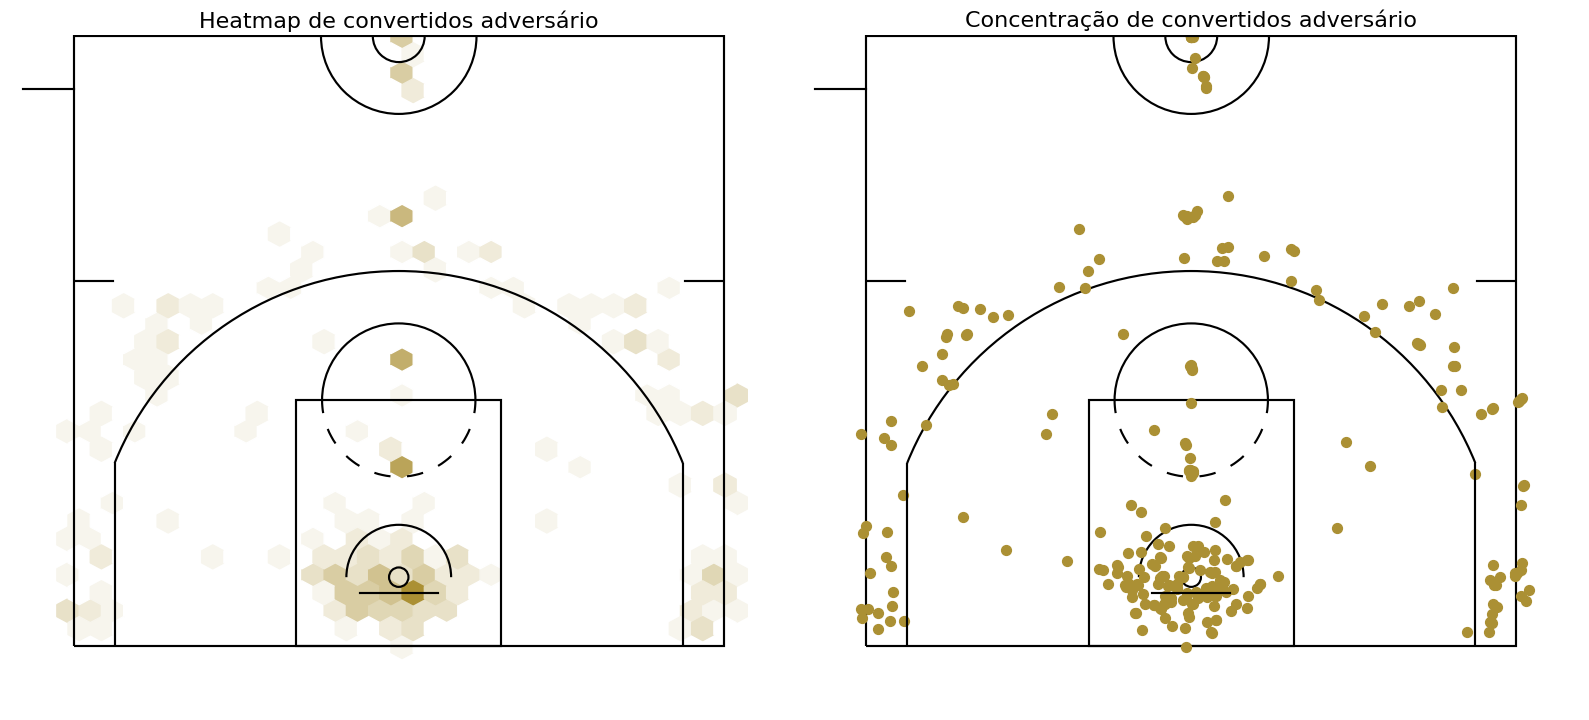

In [35]:
x_adv_c, y_adv_c = court_transform(adv_c, 'X', 'Y')

fig = shot_cart(x_adv_c, y_adv_c, cmap_c, "#AB9034", 'convertidos', 'adversário')

Observa-se uma concentração de arremessos convertidos no topo da linha de 3 pontos, nas zonas mortas da linha de 3 pontos, e perto da cesta.

Se comparado com o gráfico de arremessos errados, faz-se necessário avaliar alternativas defensivas que forcem o time adversário a arremessar mais da meia distância e das alas da linha de 3 pontos, porque são áreas da quadra onde a concentração de erros supera bastante a de acertos.

# Gráfico de arremessos do Brasília

## Arremessos errados

In [36]:
bsb_e = pd.read_csv(r"D:\PyCharm 2025.3\Projeto_final_EBAC\Shot_Charts\BSB_Errados.csv")
bsb_e.describe()

,X,Y
count,504.000000,504.000000
mean,-0.298076,4.410608
std,16.674920,25.151007
min,-24.672890,-45.657143
25%,-15.157676,-5.959490
50%,-1.619101,3.448511
75%,15.035951,20.016047
max,24.558681,48.938507


In [37]:
bsb_e = ajust_data(bsb_e, 'X', 'Y')

bsb_e.describe()

,X,Y
count,504.000000,504.000000
mean,-0.560382,2.337622
std,31.348850,13.330034
min,-46.385033,-24.198286
25%,-28.496431,-3.158530
50%,-3.043909,1.827711
75%,28.267588,10.608505
max,46.170320,25.937409


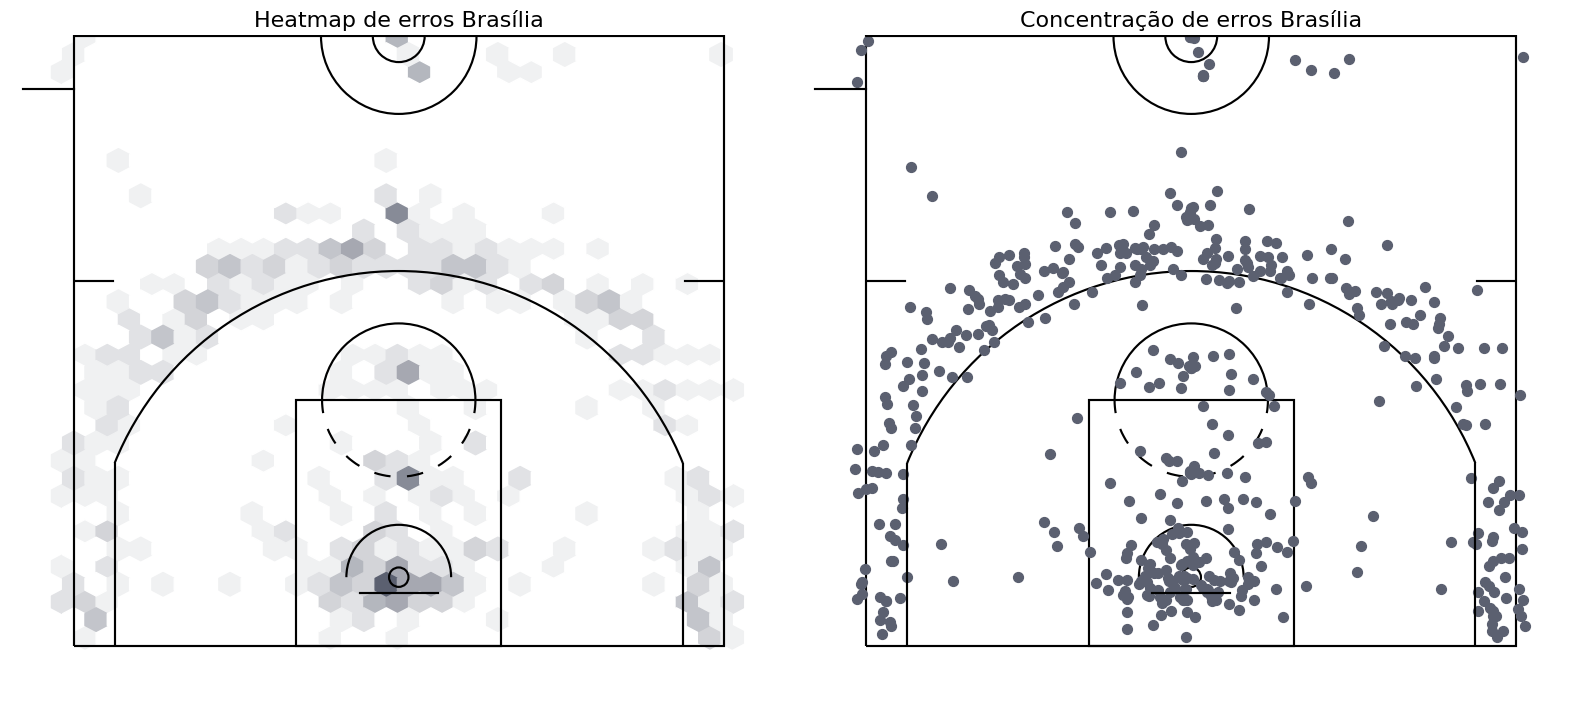

In [38]:
x_bsb_e, y_bsb_e = court_transform(bsb_e, 'X', 'Y')

fig = shot_cart(x_bsb_e, y_bsb_e, cmap_e, "#5B6070", 'erros', 'Brasília')

A distribuição de arremessos errados do Brasília é mais uniforme que a dos adversários, mas ainda com pontos de concentração perto da cesta, dentro do garrafão (incluindo a cabeça do garrafão), e no topo da linha de 3 pontos.

## Arremessos convertidos

In [39]:
bsb_c = pd.read_csv(r"D:\PyCharm 2025.3\Projeto_final_EBAC\Shot_Charts\BSB_Certos.csv")
bsb_c.describe()

,X,Y
count,287.000000,287.000000
mean,-0.249738,3.312066
std,18.370203,21.214412
min,-24.506037,-47.383675
25%,-20.695733,-1.887604
50%,-1.619101,2.064728
75%,19.974728,9.112246
max,24.285778,48.726532


In [40]:
bsb_c = ajust_data(bsb_c, 'X', 'Y')

bsb_c.describe()

,X,Y
count,287.000000,287.000000
mean,-0.469507,1.755395
std,34.535982,11.243638
min,-46.071350,-25.113348
25%,-38.907978,-1.000430
50%,-3.043909,1.094306
75%,37.552489,4.829490
max,45.657263,25.825062


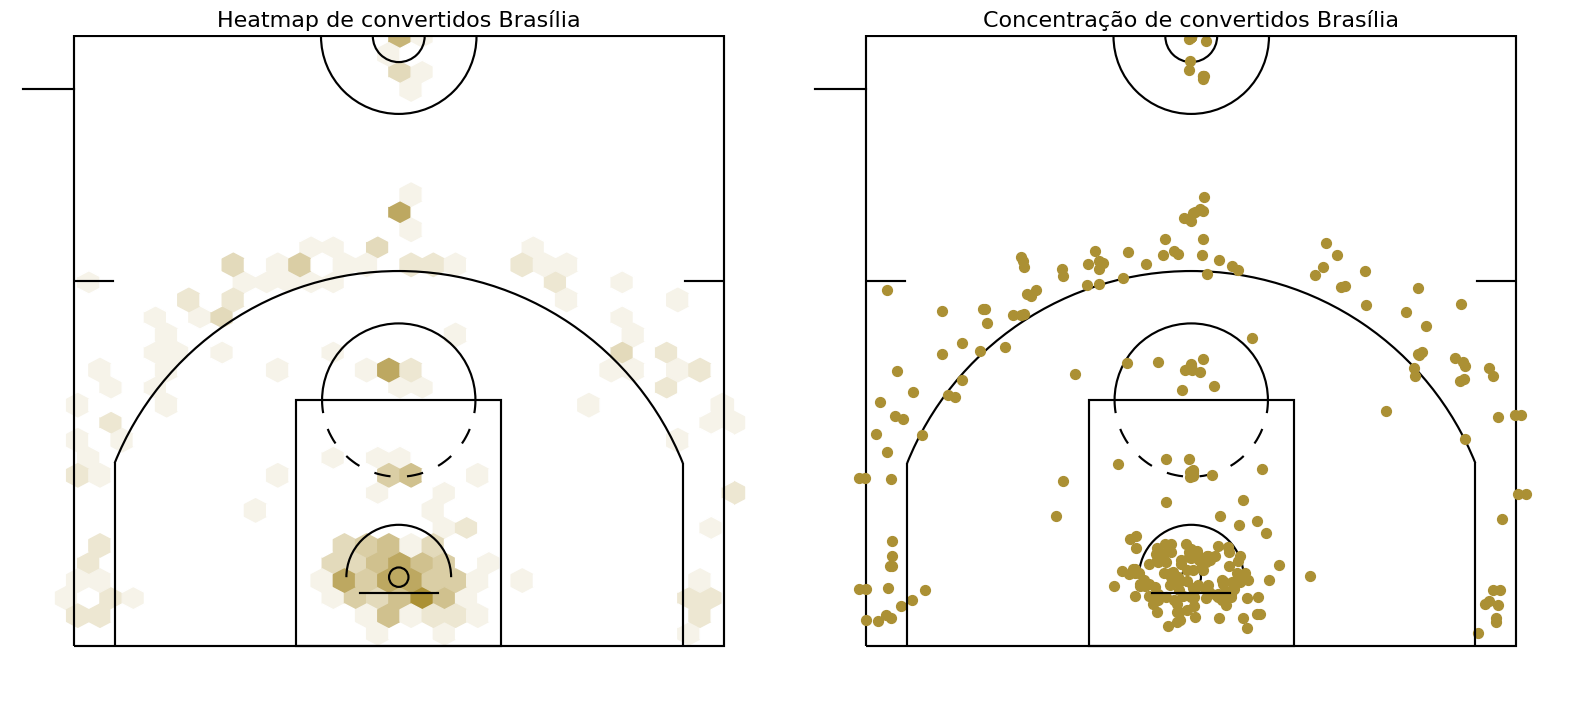

In [41]:
x_bsb_c, y_bsb_c = court_transform(bsb_c, 'X', 'Y')

fig = shot_cart(x_bsb_c, y_bsb_c, cmap_c, "#AB9034", 'convertidos', 'Brasília')

Observa-se que o gráfico de arremessos convertidos se assemelha, em termos de concentração, ao gráfico de erros. Isso significa que a equipe concentra seus ataques nessas áreas da quadra.

Tendo em vista o pequeno volume de acertos ao redor da linha de 3 pontos, em comparação com os erros, se mostra necessário melhorar o aproveitamento dessa região da quadra, não só para aumentar a diversidade ofensiva, mas também para aumentar a eficiência no garrafão (tornando esta área ainda mais efetiva para a equipe) uma vez que uma alta eficiência nos 3 pontos tende a gerar mais espaços perto da cesta.